# Linear velocity of forward swimming cells

This script quantifies the linear velocity during directed swimming. 
The registration matrix must be calculated in advance with 01-main_analysis.py

**Input:**

*file_directory* : The path to the folder containing the transformation matrices

**Output:**

*forward_linear_velocity.csv* : A csv file with the measured linear velocity of the cell.

In [ ]:
import os
import csv
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import linregress



### Input

In [2]:
### Path to registration matrices:
file_directory= "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"

### Reading the parameters file
input_parameters_path = file_directory + "parameters.csv"
input_parameters = pd.read_csv(input_parameters_path)

### Pixel size and framerate of timelapse:
pixel_size = input_parameters["pixel_size"][0]  # μm 
fps        = input_parameters["fps"][0]         # frame rate

### Reading registration matrices:
tmat_load_1 = np.load(file_directory +"tmat_rigid_body.npy")
### If registration was completed in two steps, additionally load:
tmat_load_2 = np.load(file_directory +"tmat_rigid_body_loop2.npy")

### Effective matrix:
### If registration was completed in one step:
# tmat =  tmat_load_1 # If there is 1 matrix
### If registration was completed in two steps:
tmat =  np.matmul(tmat_load_2, tmat_load_1) 

output_path = file_directory + "\\output_motility\\"
if not os.path.exists(output_path):
    os.makedirs(output_path)

### Linear velocity

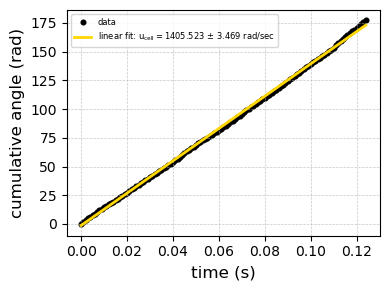

In [3]:
# Time points
time_step = 1 / fps # in sec
translations_tmat = tmat[:, :2, 2]

# Calculate cumulative distances
instantaneous_distances = np.linalg.norm(np.diff(translations_tmat*pixel_size, axis=0), axis=1)
cumulative_distance = np.concatenate(([0], np.cumsum(instantaneous_distances))) 

time_points = np.arange(len(cumulative_distance)) * time_step  # Time in seconds

# Calculate the speed with linear regression:
slope, intercept, r_value, p_value, std_err = linregress(time_points,cumulative_distance)
translation_fit = slope * time_points + intercept 

fig, ax = plt.subplots(figsize=(4, 3)) 
ax.scatter(time_points, cumulative_distance, color='black', marker='.', label="data", s=45)
ax.plot(time_points, translation_fit, color='gold', linestyle='-', lw=2, label="linear fit: u$_\mathrm{cell}=$" + str(round(slope,3)) + " ± " + str(round(std_err,3)) + " rad/sec" )
ax.set_xlabel('time (s)', fontsize=12)
ax.set_ylabel('cumulative angle (rad)', fontsize=12)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend(loc='upper left', fontsize=6)
plt.tight_layout()   
plt.show()

### Saving output

In [4]:
headers = ["slope (rad/sec)", "intercept (rad)", "r_value", "p_value", "std_err (rad/sec)"]
values = [slope, intercept, r_value, p_value, std_err]

with open(output_path +'forward_linear_velocity.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(headers)
    writer.writerow(values)